1. Import Library
Mengimpor seluruh library yang akan digunakan selama proses machine learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

2. Load Dataset
Membaca dataset ke dalam DataFrame Pandas.

In [2]:
df = pd.read_csv("../dataset/Airline_customer_satisfaction.csv")

3. Menampilkan Data Awal
Memastikan dataset berhasil dimuat dan melihat 5 data pertama.

In [3]:
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


4. Mengetahui Ukuran Dataset

In [4]:
df.shape

(129880, 22)

5. Melihat Informasi Dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

6. Statistik Deskriptif

In [6]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


7. Nama Kolom

In [7]:
df.columns

Index(['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient',
       'Food and drink', 'Gate location', 'Inflight wifi service',
       'Inflight entertainment', 'Online support', 'Ease of Online booking',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='str')

8. Cek Missing Value

In [8]:
df.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

9. Cek Data Duplikat

In [9]:
df.duplicated().sum()

np.int64(0)

10. Distribusi Target

In [10]:
df["satisfaction"].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [11]:
(df["satisfaction"].value_counts(normalize=True) * 100).round(2)

satisfaction
satisfied       54.73
dissatisfied    45.27
Name: proportion, dtype: float64

CLEANING
11. Mengatasi Missing Value

In [12]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)

12. Verifikasi Missing Value

In [13]:
df.isnull().sum()

satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

13. Verifikasi Jumlah Data

In [14]:
df.shape

(129880, 22)

Exploratory Data Analysis (EDA)

14. Distribusi Kepuasan Penumpang

Tujuan

Mengetahui jumlah penumpang yang puas dan tidak puas.

Deteksi Outlier

Tujuan

Memeriksa distribusi data numerik dan mendeteksi keberadaan outlier.
Outlier tidak dihapus karena nilainya masih wajar dalam konteks penerbangan.

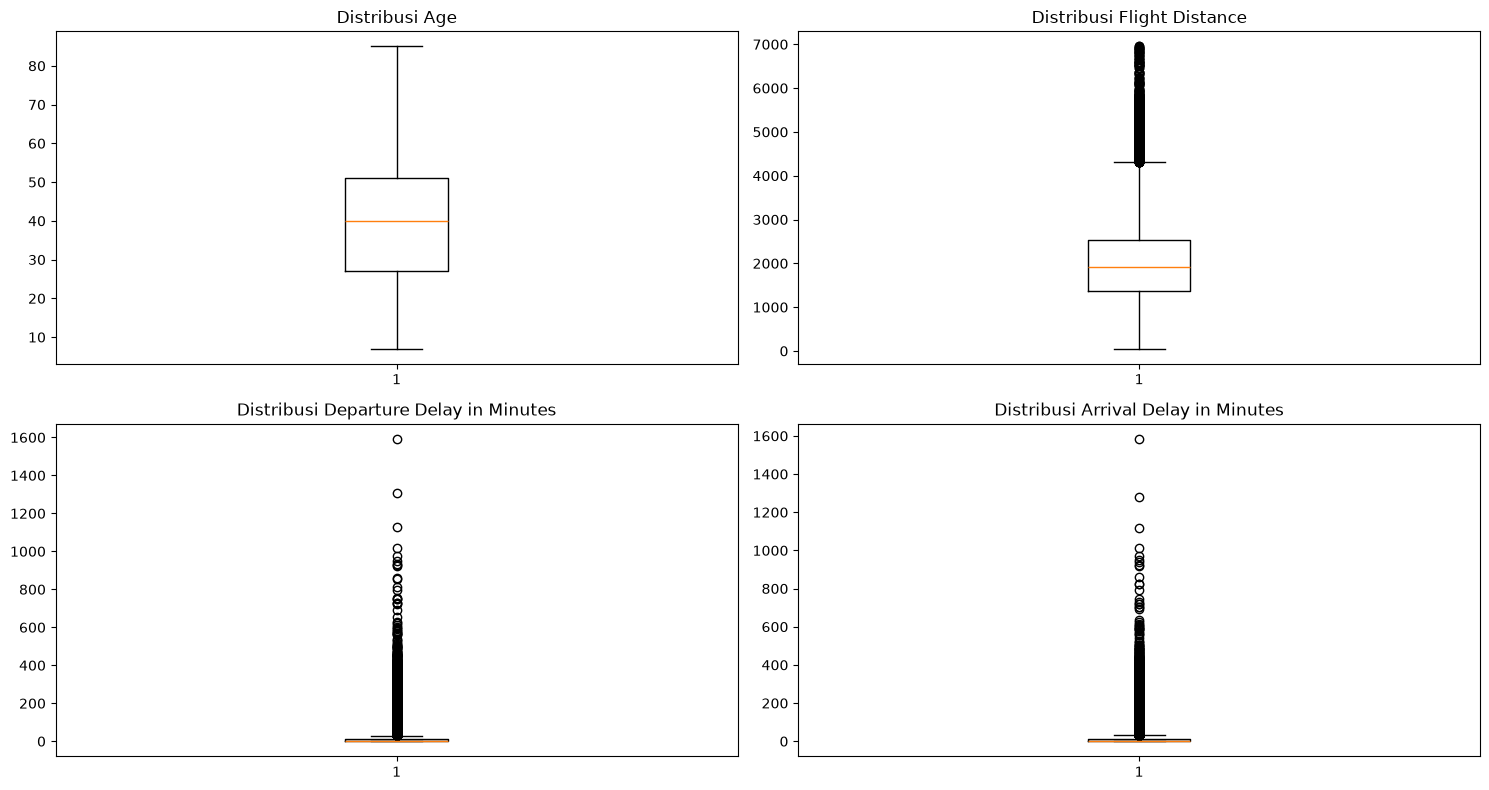

In [15]:
kolom_numerik = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

plt.figure(figsize=(15, 8))
for i, col in enumerate(kolom_numerik):
    plt.subplot(2, 2, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

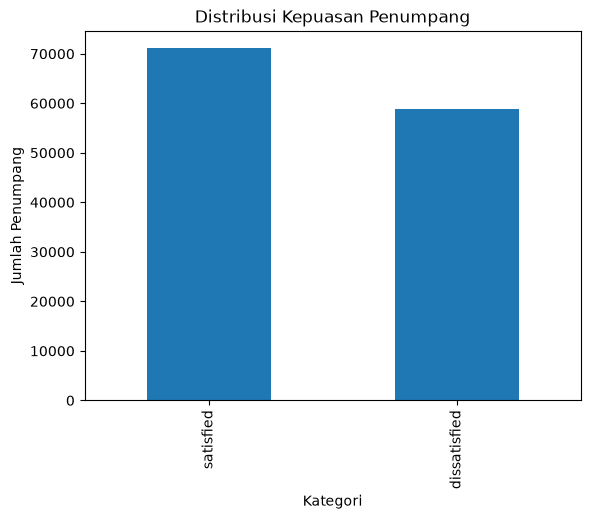

In [16]:
df["satisfaction"].value_counts().plot(kind="bar")

plt.title("Distribusi Kepuasan Penumpang")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Penumpang")

plt.show()

15. Distribusi Jenis Pelanggan

Tujuan

Mengetahui proporsi pelanggan loyal dan pelanggan baru.

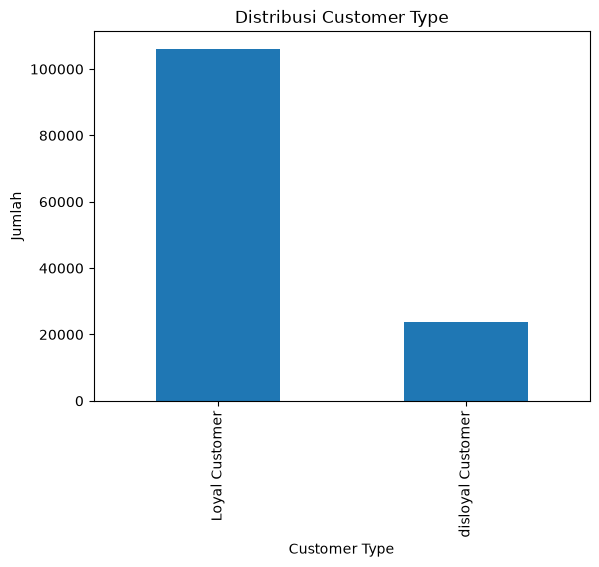

In [17]:
df["Customer Type"].value_counts().plot(kind="bar")

plt.title("Distribusi Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Jumlah")

plt.show()

16. Distribusi Kelas Penerbangan

Tujuan

Mengetahui jumlah penumpang pada setiap kelas penerbangan.

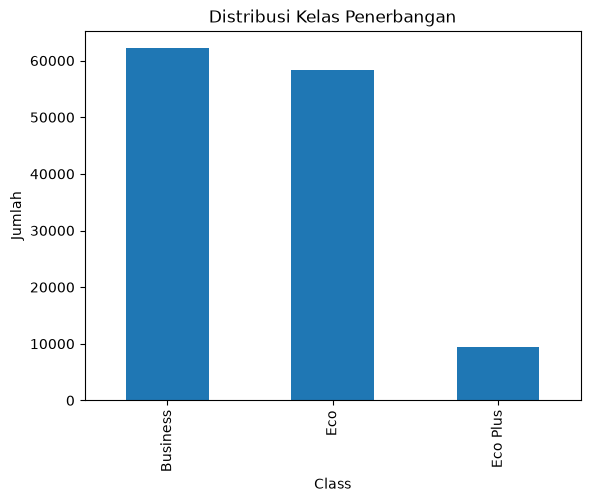

In [18]:
df["Class"].value_counts().plot(kind="bar")

plt.title("Distribusi Kelas Penerbangan")
plt.xlabel("Class")
plt.ylabel("Jumlah")

plt.show()

17. Distribusi Jenis Perjalanan

Tujuan

Mengetahui proporsi perjalanan bisnis dan perjalanan pribadi.

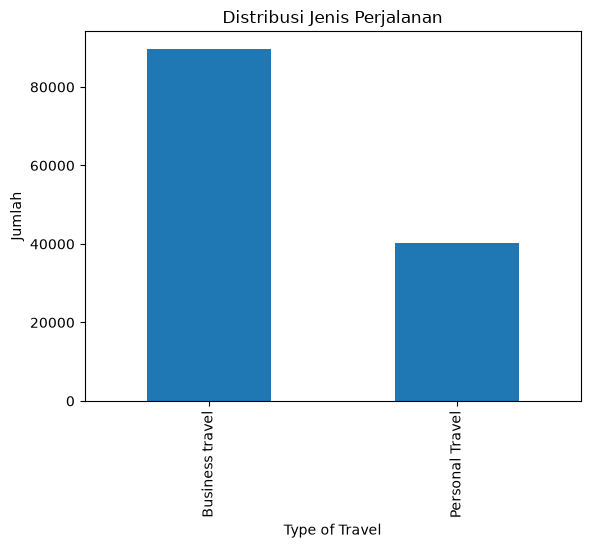

In [19]:
df["Type of Travel"].value_counts().plot(kind="bar")

plt.title("Distribusi Jenis Perjalanan")
plt.xlabel("Type of Travel")
plt.ylabel("Jumlah")

plt.show()

18. Distribusi Umur Penumpang

Tujuan

Melihat sebaran umur penumpang.

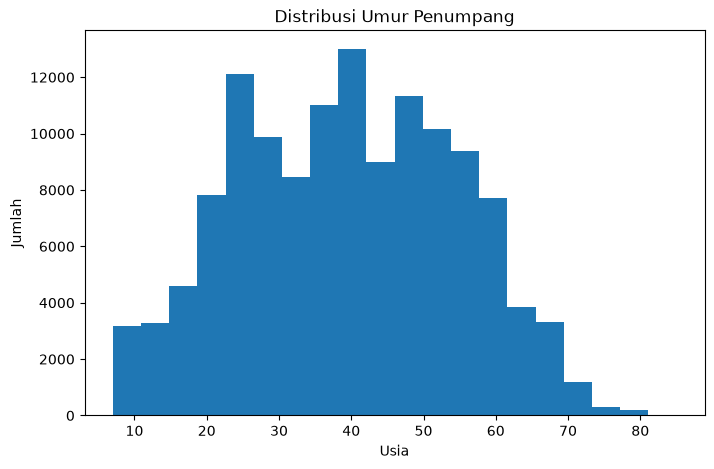

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Distribusi Umur Penumpang")
plt.xlabel("Usia")
plt.ylabel("Jumlah")

plt.show()

19. Distribusi Jarak Penerbangan

Tujuan

Melihat sebaran jarak penerbangan yang ditempuh penumpang.

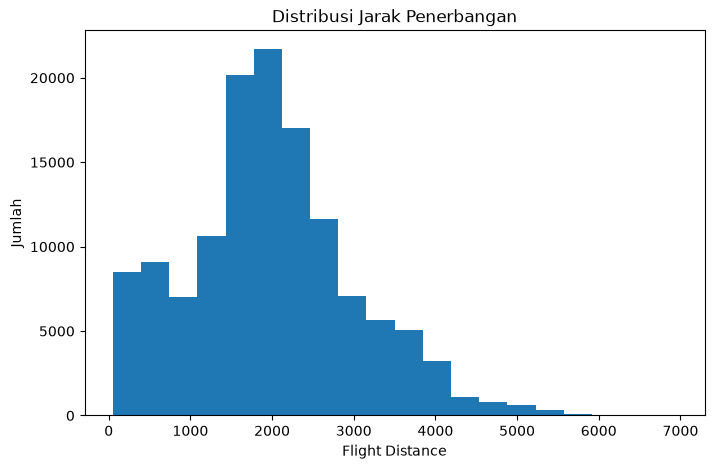

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Flight Distance"], bins=20)

plt.title("Distribusi Jarak Penerbangan")
plt.xlabel("Flight Distance")
plt.ylabel("Jumlah")

plt.show()

20. Distribusi Keterlambatan Keberangkatan

Tujuan

Melihat distribusi keterlambatan keberangkatan.

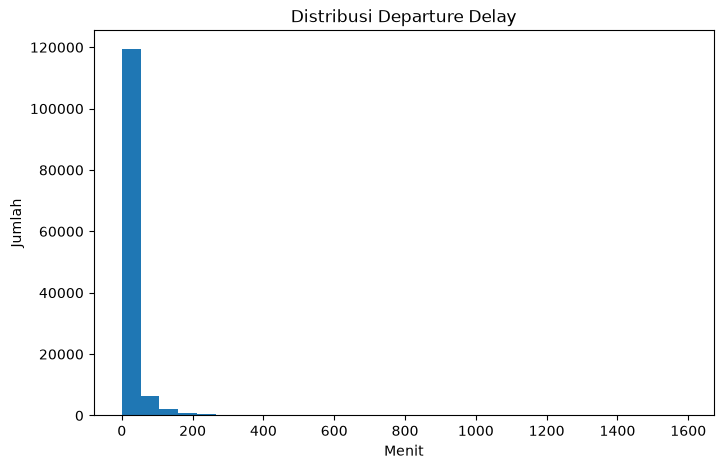

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Departure Delay in Minutes"], bins=30)

plt.title("Distribusi Departure Delay")
plt.xlabel("Menit")
plt.ylabel("Jumlah")

plt.show()

21. Distribusi Keterlambatan Kedatangan

Tujuan

Melihat distribusi keterlambatan kedatangan.

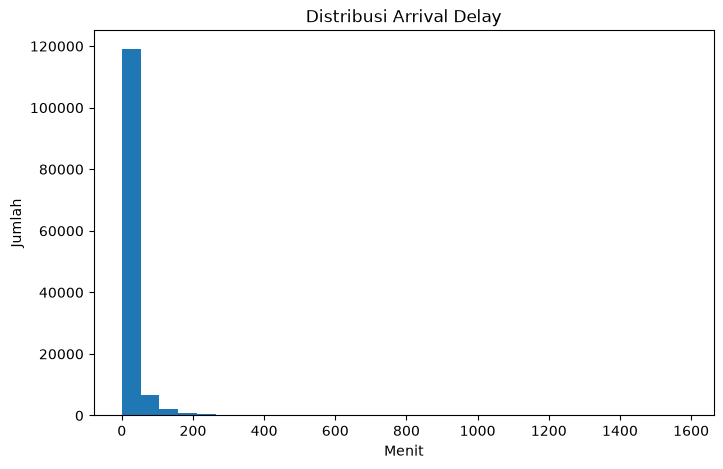

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Arrival Delay in Minutes"], bins=30)

plt.title("Distribusi Arrival Delay")
plt.xlabel("Menit")
plt.ylabel("Jumlah")

plt.show()

22. Korelasi Antar Fitur Numerik

Tujuan

Mengetahui hubungan antar fitur numerik.

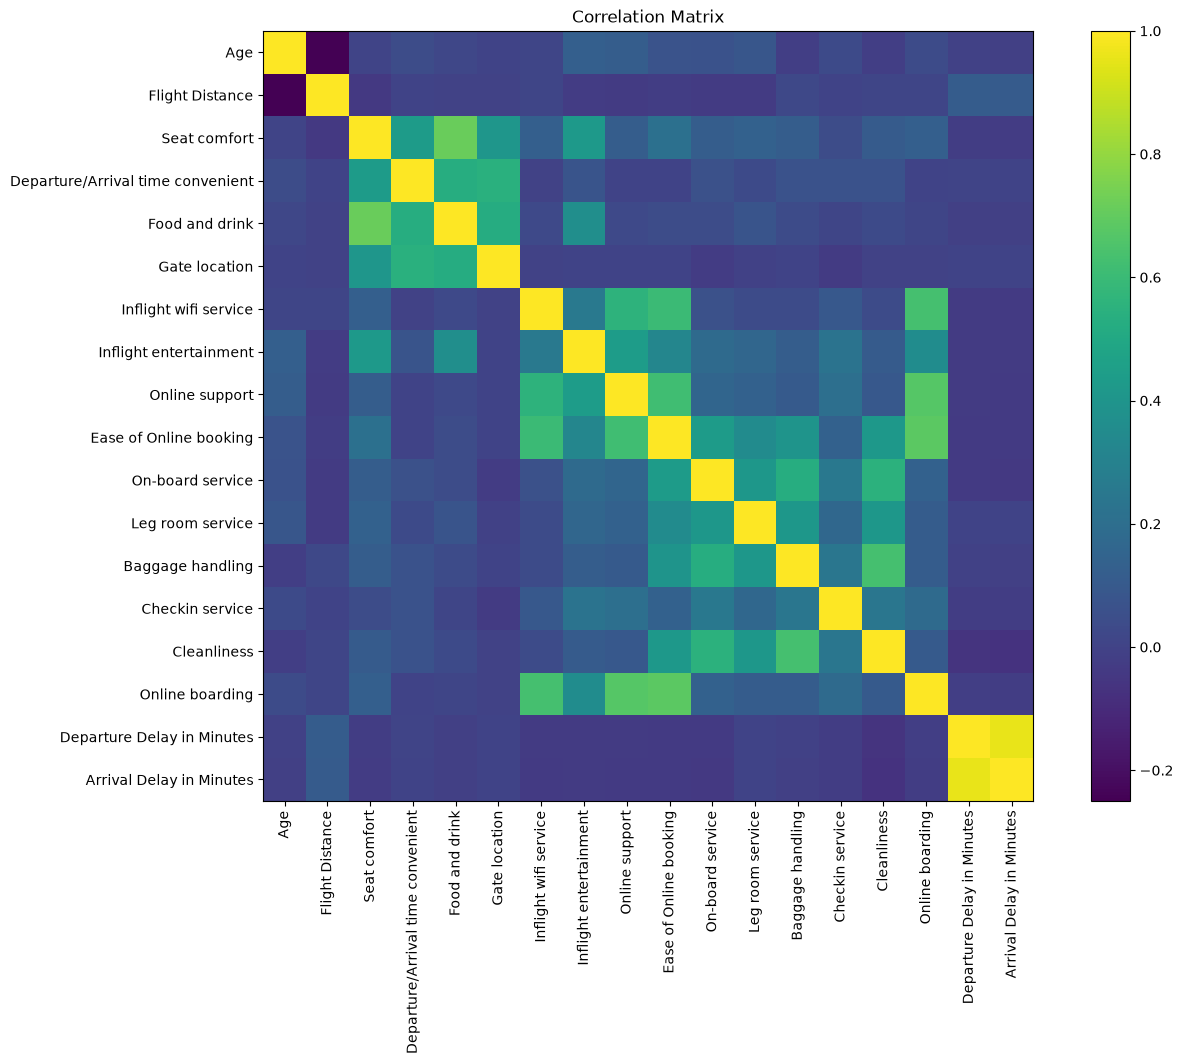

In [24]:
plt.figure(figsize=(15,10))

correlation = df.corr(numeric_only=True)

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

Data Preprocessing



23. Encoding Data Kategorikal
Tujuan

Mengubah data bertipe teks (string) menjadi angka agar dapat diproses oleh algoritma machine learning.

In [25]:
categorical_columns = [
    "satisfaction",
    "Customer Type",
    "Type of Travel",
    "Class"
]

encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    encoders[column] = encoder

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,0,65,1,1,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,0,47,1,0,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,0,15,1,1,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,0,60,1,1,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,0,70,1,1,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [26]:
import joblib

joblib.dump(
    encoders,
    "../model/label_encoders.pkl"
)

print("Encoder berhasil disimpan.")

Encoder berhasil disimpan.


24. Memastikan Encoding Berhasil

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  int64  
 1   Customer Type                      129880 non-null  int64  
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  int64  
 4   Class                              129880 non-null  int64  
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

25. Memisahkan Feature dan Target

In [28]:
X = df.drop("satisfaction", axis=1)

y = df["satisfaction"]

26. Melihat Ukuran Feature dan Target
Tujuan

Memastikan pemisahan data berhasil dilakukan.

In [29]:
print("Feature :", X.shape)

print("Target :", y.shape)

Feature : (129880, 21)
Target : (129880,)


27. Data Splitting

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

28. Verifikasi

In [31]:
print("X Train :", X_train.shape)

print("X Test :", X_test.shape)

print("y Train :", y_train.shape)

print("y Test :", y_test.shape)

X Train : (103904, 21)
X Test : (25976, 21)
y Train : (103904,)
y Test : (25976,)


29. Feature Scaling

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
import joblib

joblib.dump(
    scaler,
    "../model/standard_scaler.pkl"
)

print("Standard Scaler berhasil disimpan.")

Standard Scaler berhasil disimpan.


Training Model

1. Training Logistic Regression

30. Membuat dan melatih model

In [34]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

31. Prediksi

In [35]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

32. Evaluasi Logistic Regression

In [36]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(y_test, y_pred_logistic)

logistic_recall = recall_score(y_test, y_pred_logistic)

logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall    :", logistic_recall)
print("F1 Score  :", logistic_f1)

Accuracy : 0.8289190021558361
Precision: 0.8445321864203624
Recall    : 0.8425124850531054
F1 Score  : 0.8435211267605633


33. Classification Report

In [37]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



34. Confusion Matrix

In [38]:
cm = confusion_matrix(y_test, y_pred_logistic)

print(cm)

[[ 9554  2205]
 [ 2239 11978]]


2. Training Decision Tree

35. Membuat Model

In [39]:
decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

36. Prediksi

In [40]:
y_pred_decision_tree = decision_tree_model.predict(X_test)

37. Evaluasi

In [41]:
decision_tree_accuracy = accuracy_score(y_test, y_pred_decision_tree)

decision_tree_precision = precision_score(y_test, y_pred_decision_tree)

decision_tree_recall = recall_score(y_test, y_pred_decision_tree)

decision_tree_f1 = f1_score(y_test, y_pred_decision_tree)

print("Accuracy :", decision_tree_accuracy)
print("Precision:", decision_tree_precision)
print("Recall    :", decision_tree_recall)
print("F1 Score  :", decision_tree_f1)

Accuracy : 0.9322836464428703
Precision: 0.9377371749824315
Recall    : 0.9385946402194556
F1 Score  : 0.9381657116743417


38. Classification Report

In [42]:
print(classification_report(y_test, y_pred_decision_tree))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93     11759
           1       0.94      0.94      0.94     14217

    accuracy                           0.93     25976
   macro avg       0.93      0.93      0.93     25976
weighted avg       0.93      0.93      0.93     25976



29. Confusion Matrix

In [43]:
cm = confusion_matrix(y_test, y_pred_decision_tree)

print(cm)

[[10873   886]
 [  873 13344]]


3. Training Random Forest

40. Membuat Model

In [44]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

41. Prediksi

In [45]:
y_pred_random_forest = random_forest_model.predict(X_test)

42. Evaluasi

In [46]:
random_forest_accuracy = accuracy_score(y_test, y_pred_random_forest)

random_forest_precision = precision_score(y_test, y_pred_random_forest)

random_forest_recall = recall_score(y_test, y_pred_random_forest)

random_forest_f1 = f1_score(y_test, y_pred_random_forest)

print("Accuracy :", random_forest_accuracy)
print("Precision:", random_forest_precision)
print("Recall    :", random_forest_recall)
print("F1 Score  :", random_forest_f1)

Accuracy : 0.9558053587927318
Precision: 0.9689271618227485
Recall    : 0.9497080959414785
F1 Score  : 0.9592213697073032


43. Classification Report

In [47]:
print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     11759
           1       0.97      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.95      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



44. Confusion Matrix

In [48]:
cm = confusion_matrix(y_test, y_pred_random_forest)

print(cm)

[[11326   433]
 [  715 13502]]


4. Training XGBoost

45. Membuat Model

In [49]:
xgboost_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgboost_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


46. Prediksi

In [50]:
y_pred_xgboost = xgboost_model.predict(X_test)

47. Evaluasi

In [51]:
xgboost_accuracy = accuracy_score(y_test, y_pred_xgboost)

xgboost_precision = precision_score(y_test, y_pred_xgboost)

xgboost_recall = recall_score(y_test, y_pred_xgboost)

xgboost_f1 = f1_score(y_test, y_pred_xgboost)

print("Accuracy :", xgboost_accuracy)
print("Precision:", xgboost_precision)
print("Recall    :", xgboost_recall)
print("F1 Score  :", xgboost_f1)

Accuracy : 0.9580381890976286
Precision: 0.9703332139018273
Recall    : 0.9524512907083069
F1 Score  : 0.961309101235269


48. Classification Report

In [52]:
print(classification_report(y_test, y_pred_xgboost))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     11759
           1       0.97      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



49. Confusion Matrix

In [53]:
cm = confusion_matrix(y_test, y_pred_xgboost)

print(cm)

[[11345   414]
 [  676 13541]]


Model Comparison

50. Membuat Tabel Perbandingan

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgboost_accuracy
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        xgboost_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        xgboost_recall
    ],
    "F1 Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        xgboost_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.828919,0.844532,0.842512,0.843521
1,Decision Tree,0.932284,0.937737,0.938595,0.938166
2,Random Forest,0.955805,0.968927,0.949708,0.959221
3,XGBoost,0.958038,0.970333,0.952451,0.961309


51. Mengurutkan Model Terbaik

In [55]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.958038,0.970333,0.952451,0.961309
2,Random Forest,0.955805,0.968927,0.949708,0.959221
1,Decision Tree,0.932284,0.937737,0.938595,0.938166
0,Logistic Regression,0.828919,0.844532,0.842512,0.843521


52. Grafik Perbandingan Accuracy

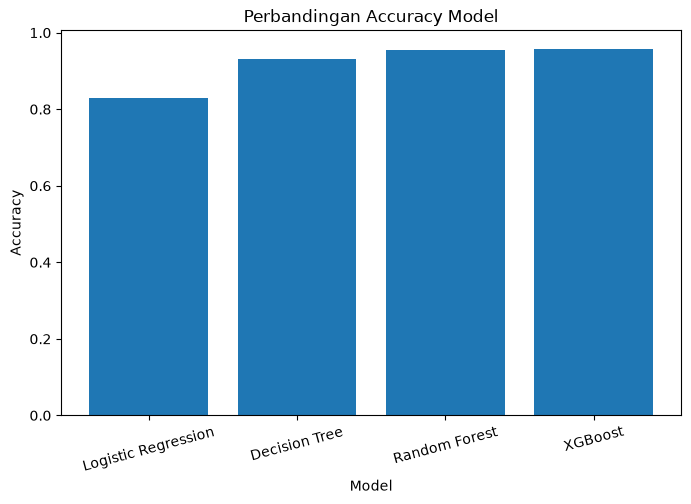

In [56]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Perbandingan Accuracy Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

53. Grafik Perbandingan F1 Score

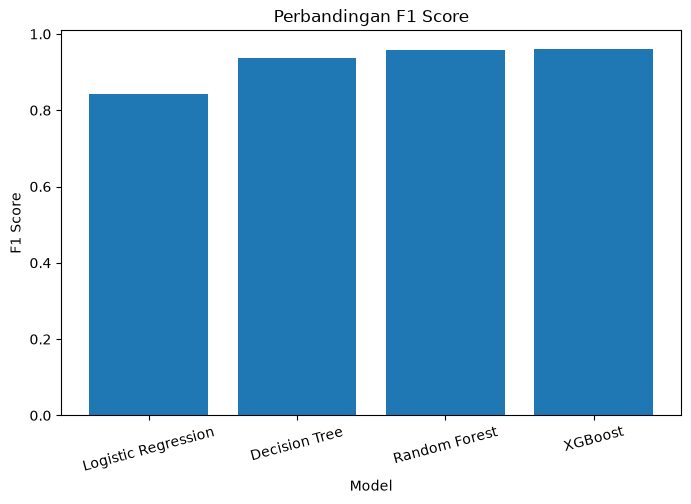

In [57]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.title("Perbandingan F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()

54. Grafik Accuracy

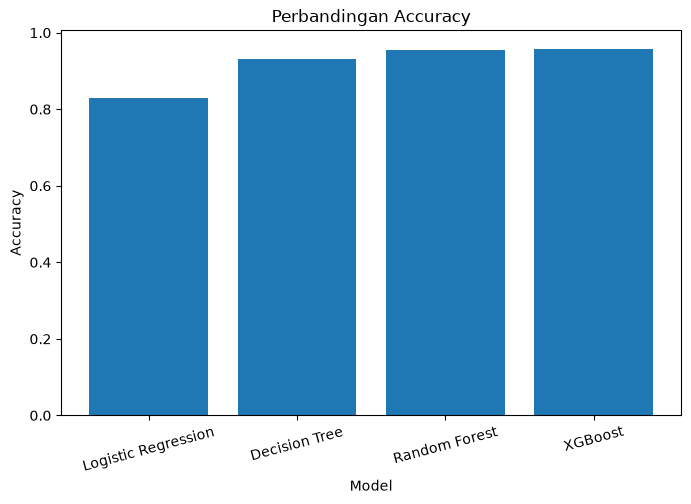

In [58]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Perbandingan Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

55. Grafik Precision

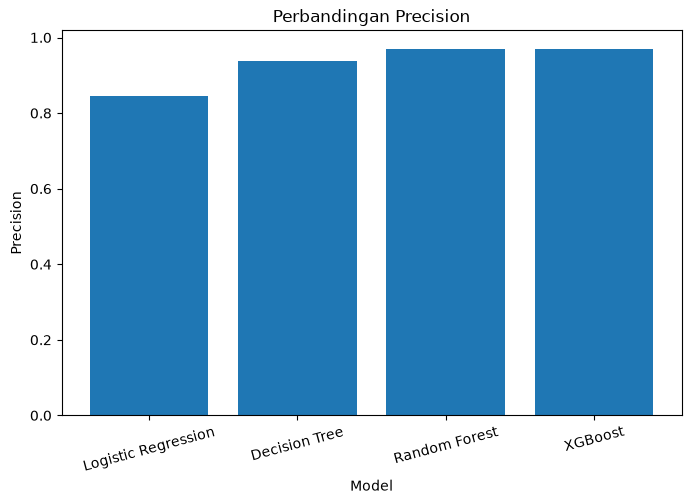

In [59]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Precision"])

plt.title("Perbandingan Precision")
plt.xlabel("Model")
plt.ylabel("Precision")

plt.xticks(rotation=15)

plt.show()

56. Grafik Recall

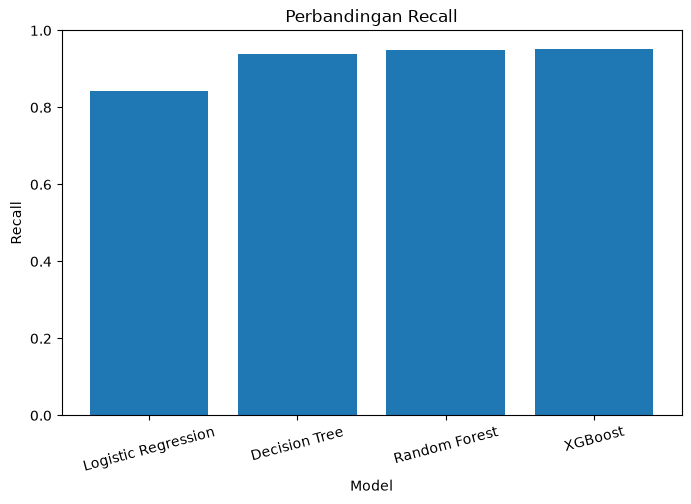

In [60]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Recall"])

plt.title("Perbandingan Recall")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.xticks(rotation=15)

plt.show()

57. Feature Importance

In [61]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,Inflight entertainment,0.202717
5,Seat comfort,0.140070
12,Ease of Online booking,0.077873
11,Online support,0.059079
7,Food and drink,0.045281
13,On-board service,0.044433
0,Customer Type,0.042644
14,Leg room service,0.040795
4,Flight Distance,0.039984
3,Class,0.036955


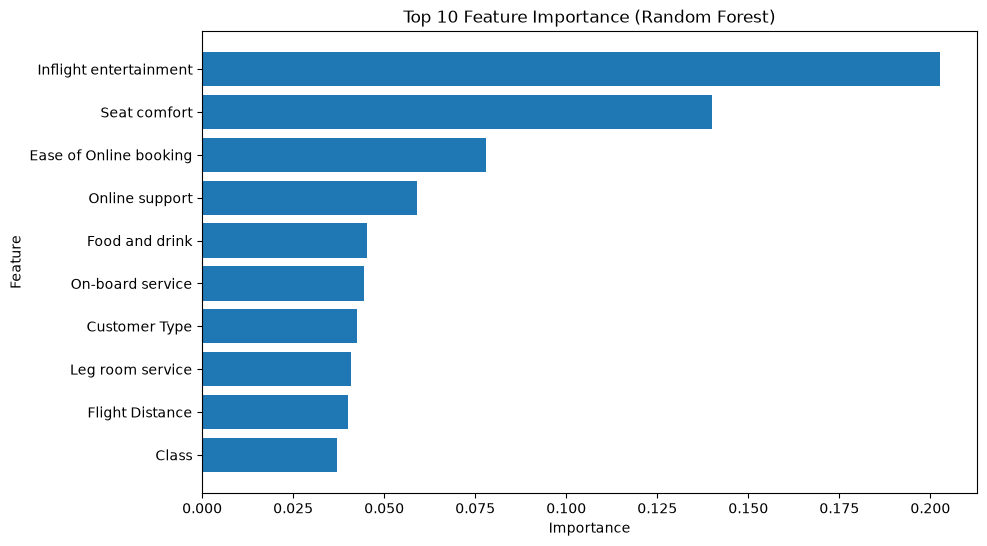

In [62]:
top_feature = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_feature["Feature"],
    top_feature["Importance"]
)

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

58. Conclusion

In [63]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("Model Terbaik")
print(best_model)

Model Terbaik
Model         XGBoost
Accuracy     0.958038
Precision    0.970333
Recall       0.952451
F1 Score     0.961309
Name: 3, dtype: object


ROC Curve
Membandingkan kemampuan keempat model dalam membedakan kelas Satisfied dan Dissatisfied berdasarkan nilai AUC (Area Under Curve).

59. Menghitung Probabilitas Prediksi

In [64]:
# Logistic Regression
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Decision Tree
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]

# Random Forest
y_prob_random_forest = random_forest_model.predict_proba(X_test)[:, 1]

# XGBoost
y_prob_xgboost = xgboost_model.predict_proba(X_test)[:, 1]

60. Menghitung ROC dan AUC

In [65]:
# Logistic Regression
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
auc_logistic = roc_auc_score(y_test, y_prob_logistic)

# Decision Tree
fpr_decision_tree, tpr_decision_tree, _ = roc_curve(y_test, y_prob_decision_tree)
auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)

# Random Forest
fpr_random_forest, tpr_random_forest, _ = roc_curve(y_test, y_prob_random_forest)
auc_random_forest = roc_auc_score(y_test, y_prob_random_forest)

# XGBoost
fpr_xgboost, tpr_xgboost, _ = roc_curve(y_test, y_prob_xgboost)
auc_xgboost = roc_auc_score(y_test, y_prob_xgboost)

61. Menampilkan ROC Curve Semua Model

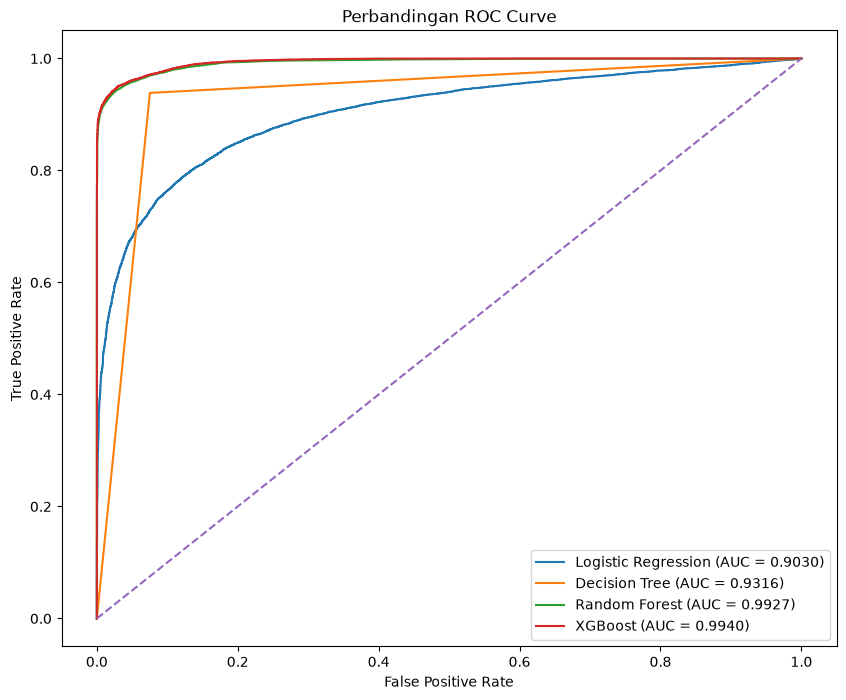

In [66]:
plt.figure(figsize=(10,8))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.4f})"
)

plt.plot(
    fpr_decision_tree,
    tpr_decision_tree,
    label=f"Decision Tree (AUC = {auc_decision_tree:.4f})"
)

plt.plot(
    fpr_random_forest,
    tpr_random_forest,
    label=f"Random Forest (AUC = {auc_random_forest:.4f})"
)

plt.plot(
    fpr_xgboost,
    tpr_xgboost,
    label=f"XGBoost (AUC = {auc_xgboost:.4f})"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Perbandingan ROC Curve")

plt.legend()

plt.show()

Cross Validation (5-Fold)

Tujuan

Membandingkan performa keempat model menggunakan 5-Fold Cross Validation
agar hasil evaluasi lebih reliable dan tidak bergantung pada satu kali split.

In [67]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'XGBoost': xgboost_model
}

cv_results = []

for name, model in models_cv.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    cv_results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std()
    })

    print(f'{name}')
    print(f'  Accuracy setiap fold : {scores}')
    print(f'  Rata-rata Accuracy   : {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

Logistic Regression
  Accuracy setiap fold : [0.82936336 0.83018142 0.82840094 0.82960397 0.82617902]
  Rata-rata Accuracy   : 0.8287 (+/- 0.0014)

Decision Tree
  Accuracy setiap fold : [0.93412252 0.93210144 0.93354507 0.93012848 0.93532243]
  Rata-rata Accuracy   : 0.9330 (+/- 0.0018)

Random Forest
  Accuracy setiap fold : [0.95442953 0.95346711 0.95486261 0.95404456 0.95558229]
  Rata-rata Accuracy   : 0.9545 (+/- 0.0007)

XGBoost
  Accuracy setiap fold : [0.95621    0.95462201 0.95592127 0.95548819 0.95577478]
  Rata-rata Accuracy   : 0.9556 (+/- 0.0005)



Tabel Hasil Cross Validation

In [68]:
cv_df = pd.DataFrame(cv_results)
cv_df

,Model,Mean Accuracy,Std
0,Logistic Regression,0.828746,0.001406
1,Decision Tree,0.933044,0.001789
2,Random Forest,0.954477,0.000718
3,XGBoost,0.955603,0.000543


Grafik Cross Validation

Tujuan

Memvisualisasikan perbandingan akurasi keempat model berdasarkan 5-Fold CV.

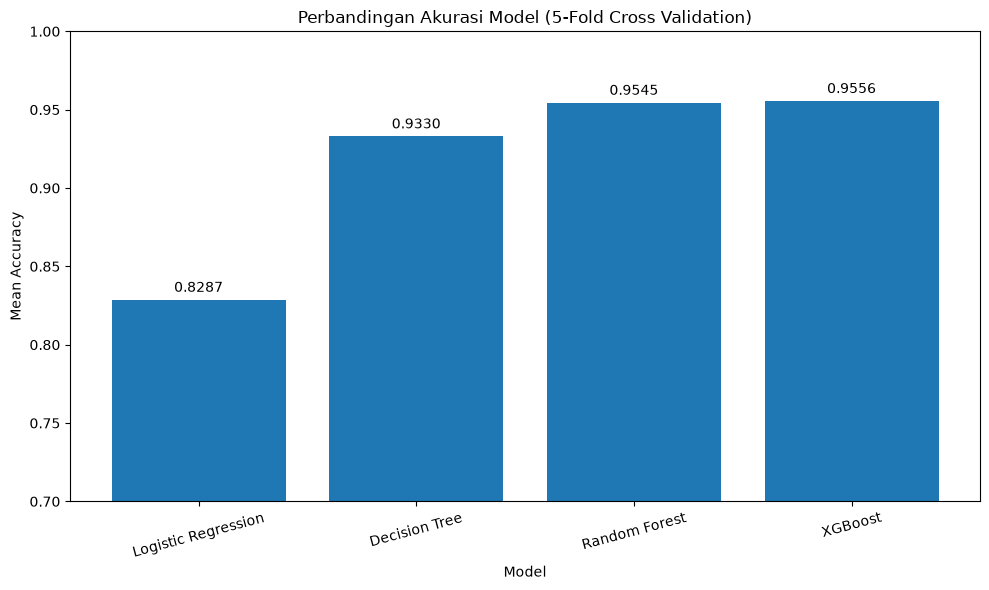

In [69]:
plt.figure(figsize=(10, 6))

plt.bar(cv_df['Model'], cv_df['Mean Accuracy'])

plt.title('Perbandingan Akurasi Model (5-Fold Cross Validation)')
plt.xlabel('Model')
plt.ylabel('Mean Accuracy')

plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)

for i, v in enumerate(cv_df['Mean Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

Hyperparameter Tuning

Tujuan

Mencari kombinasi parameter terbaik untuk setiap model menggunakan RandomizedSearchCV
agar perbandingan antar model lebih fair.

In [70]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

best_models = {}
tuning_results = []

for name in base_models:
    print(f'Tuning {name}...')

    if name == 'Logistic Regression':
        X_tr = X_train_scaled
    else:
        X_tr = X_train

    search = RandomizedSearchCV(
        estimator=base_models[name],
        param_distributions=param_grids[name],
        n_iter=5,
        cv=3,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_tr, y_train)

    best_models[name] = search.best_estimator_

    tuning_results.append({
        'Model': name,
        'Best Score (CV)': search.best_score_,
        'Best Params': str(search.best_params_)
    })

    print(f'  Best Score : {search.best_score_:.4f}')
    print(f'  Best Params: {search.best_params_}')
    print()

Tuning Logistic Regression...
  Best Score : 0.8289
  Best Params: {'solver': 'liblinear', 'C': 0.01}

Tuning Decision Tree...
  Best Score : 0.9369
  Best Params: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}

Tuning Random Forest...
  Best Score : 0.9536
  Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}

Tuning XGBoost...
  Best Score : 0.9550
  Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}



Tabel Hasil Tuning

In [71]:
tuning_df = pd.DataFrame(tuning_results)
tuning_df

,Model,Best Score (CV),Best Params
0,Logistic Regression,0.828871,"{'solver': 'liblinear', 'C': 0.01}"
1,Decision Tree,0.936874,"{'min_samples_split': 10, 'min_samples_leaf': ..."
2,Random Forest,0.953640,"{'n_estimators': 100, 'min_samples_split': 2, ..."
3,XGBoost,0.954978,"{'subsample': 0.8, 'n_estimators': 100, 'max_d..."


Evaluasi Model Setelah Tuning

Tujuan

Mengevaluasi ulang performa keempat model setelah parameter dioptimasi.

In [72]:
tuned_results = []

for name, model in best_models.items():
    if name == 'Logistic Regression':
        y_pred_tuned = model.predict(X_test_scaled)
        y_prob_tuned = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_tuned = model.predict(X_test)
        y_prob_tuned = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred_tuned)
    auc = roc_auc_score(y_test, y_prob_tuned)

    tuned_results.append({
        'Model': name,
        'Accuracy (Tuned)': acc,
        'ROC-AUC (Tuned)': auc
    })

    print(f'=== {name} (Tuned) ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred_tuned))
    print('-' * 50)

tuned_df = pd.DataFrame(tuned_results)
tuned_df

=== Logistic Regression (Tuned) ===
Accuracy : 0.8288
ROC-AUC  : 0.9030
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976

--------------------------------------------------
=== Decision Tree (Tuned) ===
Accuracy : 0.9399
ROC-AUC  : 0.9780
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     11759
           1       0.96      0.93      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976

--------------------------------------------------
=== Random Forest (Tuned) ===
Accuracy : 0.9558
ROC-AUC  : 0.9927
              precision    recall  f1-sc

,Model,Accuracy (Tuned),ROC-AUC (Tuned)
0,Logistic Regression,0.828842,0.902988
1,Decision Tree,0.939945,0.978044
2,Random Forest,0.955805,0.992688
3,XGBoost,0.956729,0.993847


Perbandingan Sebelum dan Sesudah Tuning

Tujuan

Membandingkan performa model sebelum dan sesudah hyperparameter tuning
untuk melihat apakah tuning memberikan peningkatan.

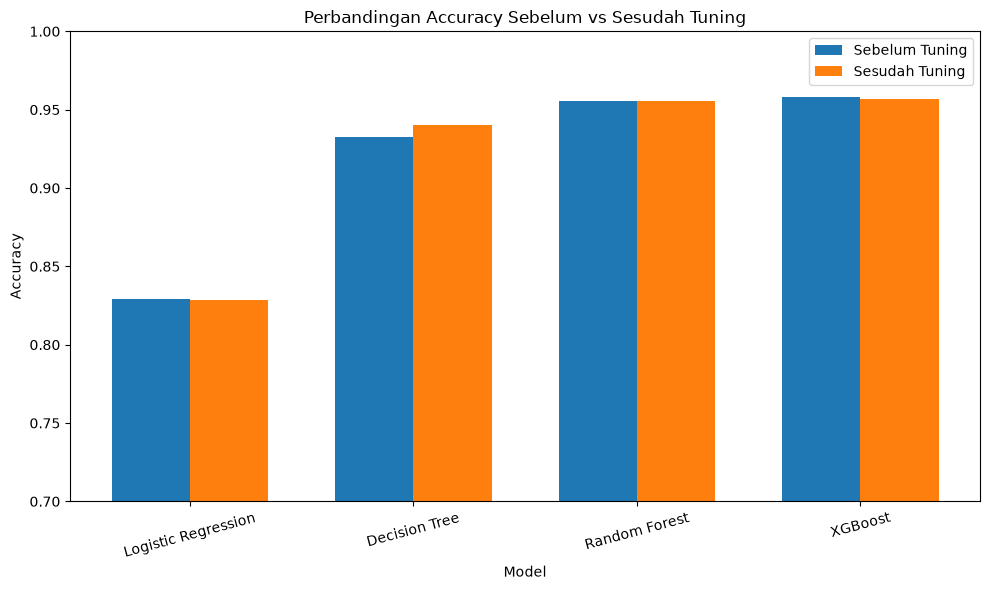

In [73]:
before = comparison[['Model', 'Accuracy']].copy()
before['Kondisi'] = 'Sebelum Tuning'

after = tuned_df[['Model', 'Accuracy (Tuned)']].copy()
after = after.rename(columns={'Accuracy (Tuned)': 'Accuracy'})
after['Kondisi'] = 'Sesudah Tuning'

compare_tuning = pd.concat([before, after], ignore_index=True)

plt.figure(figsize=(10, 6))

x = np.arange(len(before))
width = 0.35

plt.bar(x - width/2, before['Accuracy'], width, label='Sebelum Tuning')
plt.bar(x + width/2, after['Accuracy'], width, label='Sesudah Tuning')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Perbandingan Accuracy Sebelum vs Sesudah Tuning')
plt.xticks(x, before['Model'], rotation=15)
plt.ylim(0.7, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [74]:
import joblib

In [75]:
joblib.dump(
    best_models['Logistic Regression'],
    "../model/logistic_regression.pkl"
)

print("Logistic Regression (Tuned) berhasil disimpan.")

Logistic Regression (Tuned) berhasil disimpan.


In [76]:
joblib.dump(
    best_models['Decision Tree'],
    "../model/decision_tree.pkl"
)

print("Decision Tree (Tuned) berhasil disimpan.")

Decision Tree (Tuned) berhasil disimpan.


In [77]:
joblib.dump(
    best_models['Random Forest'],
    "../model/random_forest.pkl"
)

print("Random Forest (Tuned) berhasil disimpan.")

Random Forest (Tuned) berhasil disimpan.


In [78]:
joblib.dump(
    best_models['XGBoost'],
    "../model/xgboost.pkl"
)

print("XGBoost (Tuned) berhasil disimpan.")

XGBoost (Tuned) berhasil disimpan.


In [79]:
import joblib

joblib.dump(scaler, "../model/standard_scaler.pkl")

print("Standard Scaler berhasil disimpan.")

Standard Scaler berhasil disimpan.
